In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Etape 1 : Scale-space Extrema Detection

In [2]:
def build_gaussian_kernels(sigma, num_scales):
    """
    Génère les valeurs de sigma pour toutes les échelles d'une octave.

    Args:
        sigma (float): Sigma de base (écart-type du flou).
        num_scales (int): Nombre d'échelles actives par octave (typiquement 3).

    Returns:
        list[float]: Liste de (num_scales + 3) valeurs de sigma pour l'octave.
                     (+3 pour disposer d'images supplémentaires nécessaires au DoG).
    """
    # facteur entre deux niveaux consécutifs : k^num_scales = 2  =>  k = 2^(1/num_scales)
    k = 2 ** (1.0 / num_scales)

    # Sigmas : sigma * k^i pour i = 0..num_scales+2 (num_scales + 3 valeurs)
    return [sigma * (k ** i) for i in range(num_scales + 3)]

def build_gaussian_octaves(image, num_octaves=4, num_scales=3, sigma=1.6):
    """
    Construit la pyramide gaussienne (octaves) :
    - chaque octave contient (num_scales + 3) images floutées (pour construire DoG),
    - entre deux octaves on sous-échantillonne par 2.

    Args:
        image (np.ndarray): Image d'entrée (float ou uint8). Si uint8, la fonction
                            convertit en float32 mais ne normalise pas les valeurs.
        num_octaves (int): Nombre d'octaves à construire.
        num_scales (int): Nombre d'échelles actives par octave (Lowe recommande 3).
        sigma (float): Sigma de base (Lowe recommande 1.6).

    Returns:
        list[list[np.ndarray]]: Liste d'octaves; chaque octave est une liste d'images
                                floutées (dtype float32).
    Notes:
        - On applique cv2.GaussianBlur avec kernel automatique (0,0) pour laisser OpenCV
          choisir la taille du noyau en fonction du sigma.
        - Le sous-échantillonnage utilise INTER_NEAREST pour éviter d'ajouter du flou
          non souhaité lors du redimensionnement.
    """
    octaves = []

    # Travailler en float32 pour stabilité des filtres
    base = image.astype(np.float32)

    for o in range(num_octaves):
        # calculer la liste des sigmas pour cette octave
        sigmas = build_gaussian_kernels(sigma, num_scales)
        gaussian_images = []

        for s in sigmas:
            # flou gaussien isotrope avec sigma s
            blurred = cv2.GaussianBlur(base, (0, 0), sigmaX=s, sigmaY=s)
            gaussian_images.append(blurred)

        octaves.append(gaussian_images)

        # préparer l'image de base pour l'octave suivante : sous-échantillonnage ×2
        base = cv2.resize(base, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_NEAREST)

    return octaves

In [3]:
def generateDoGImages(gaussian_images):
    """
    Génère les images de différence de gaussiennes (DoG) à partir des images gaussiennes.
    
    Args:
        gaussian_images (list): Liste d'octaves, où chaque octave contient une liste
                                d'images gaussiennes avec différents niveaux de flou.
    
    Returns:
        list: Liste d'octaves DoG, où chaque octave contient (num_scales + 2) images DoG.
              Chaque image DoG est la différence entre deux images gaussiennes consécutives.
    """
    dog_images = []
    
    for gaussian_images_in_octave in gaussian_images:
        dog_images_in_octave = []
        
        # Calculer la différence entre images gaussiennes consécutives
        for first_image, second_image in zip(gaussian_images_in_octave, gaussian_images_in_octave[1:]):
            # Conversion en float pour gérer les valeurs négatives
            dog = (second_image.astype(float) - first_image.astype(float))
            dog_images_in_octave.append(dog)
            
        dog_images.append(dog_images_in_octave)
        
    return dog_images

In [4]:
def is_extremum(dog, s, y, x):
    """
    Vérifie si un point est un extremum local (maximum ou minimum) dans l'espace-échelle 3D.
    
    Compare le point central avec ses 26 voisins (8 dans l'échelle actuelle, 9 dans l'échelle
    supérieure et 9 dans l'échelle inférieure).
    
    Args:
        dog (numpy.ndarray): Pile d'images DoG pour une octave (shape: [num_scales, height, width]).
        s (int): Index de l'échelle (scale).
        y (int): Coordonnée Y du point.
        x (int): Coordonnée X du point.
    
    Returns:
        bool: True si le point est un extremum local, False sinon.
    """
    # Extraire le voisinage 3x3x3 centré sur le point
    patch = dog[s-1:s+2, y-1:y+2, x-1:x+2]
    center = patch[1, 1, 1]
    
    # Vérifier si c'est un maximum ou un minimum
    if center > 0:
        return center == patch.max()
    else:
        return center == patch.min()




def detect_keypoints_in_dog(dog_octaves):
    """
    Détecte les extrema 3D dans la pyramide DoG.
    
    Parcourt toutes les octaves et toutes les échelles (sauf les bords) pour identifier
    les points qui sont des extrema locaux dans l'espace-échelle.
    
    Args:
        dog_octaves (list): Liste d'octaves DoG, où chaque octave contient plusieurs
                            images DoG à différentes échelles.
    
    Returns:
        list: Liste de tuples (octave, scale, y, x) représentant les keypoints bruts détectés.
    """
    keypoints = []
    
    for o, dog in enumerate(dog_octaves):
        dog = np.array(dog)  # Conversion en array 3D [scales, height, width]
        
        # Parcourir les échelles et les pixels (éviter les bords : première et dernière)
        for s in range(1, dog.shape[0] - 1):
            for y in range(1, dog.shape[1] - 1):
                for x in range(1, dog.shape[2] - 1):
                    if is_extremum(dog, s, y, x):
                        keypoints.append((o, s, y, x))
    return keypoints

#### Fonction réunissant toute l'étape 1:

In [5]:
def scaleSpaceExtremaDetection(img, num_octaves=4, num_scales=3, sigma=1.6):
    """
    Étape 1 de SIFT : Détection des extrema dans l'espace-échelle.
    
    Cette fonction combine la construction de la pyramide gaussienne, la génération
    des images DoG, et la détection des extrema locaux.
    
    Args:
        img (numpy.ndarray): Image en niveaux de gris normalisée [0, 1].
        num_octaves (int): Nombre d'octaves de la pyramide. Default: 4.
        num_scales (int): Nombre d'échelles par octave. Default: 3.
        sigma (float): Sigma de base pour le flou gaussien. Default: 1.6.
    
    Returns:
        tuple: (gaussian_octaves, dog_octaves, raw_keypoints)
            - gaussian_octaves: Pyramide d'images gaussiennes
            - dog_octaves: Pyramide d'images DoG
            - raw_keypoints: Liste des keypoints bruts (avant localisation précise)
    """
    print(f"[INFO] Taille de l'image chargée : {img.shape}")

    gaussian_octaves = build_gaussian_octaves(img, num_octaves=num_octaves, 
                                               num_scales=num_scales, sigma=sigma)
    
    dog_octaves = generateDoGImages(gaussian_octaves)
    print("[INFO] Octaves DoG construites.")

    raw_keypoints = detect_keypoints_in_dog(dog_octaves)
    print(f"[INFO] Keypoints bruts détectés : {len(raw_keypoints)}")
    
    return gaussian_octaves, dog_octaves, raw_keypoints

# Etape 2 : Keypoint Localization

In [6]:
def localize_keypoint(dog, s, y, x):
    """
    Localisation sub-pixel d'un keypoint par approximation quadratique (Taylor).
    
    Utilise les dérivées premières (gradient) et secondes (Hessienne) pour estimer
    l'offset sub-pixel de l'extremum par rapport à la position discrète.
    
    Args:
        dog (numpy.ndarray): Pile d'images DoG pour une octave.
        s (int): Index de l'échelle.
        y (int): Coordonnée Y du point.
        x (int): Coordonnée X du point.
    
    Returns:
        numpy.ndarray: Offset 3D [dx, dy, ds] pour la position sub-pixel de l'extremum.
    """
    # Calcul du gradient
    dx = (dog[s, y, x+1] - dog[s, y, x-1]) / 2
    dy = (dog[s, y+1, x] - dog[s, y-1, x]) / 2
    ds = (dog[s+1, y, x] - dog[s-1, y, x]) / 2
    gradient = np.array([dx, dy, ds])

    # Calcul de la Hessienne simplifiée
    dxx = dog[s, y, x+1] + dog[s, y, x-1] - 2*dog[s, y, x]
    dyy = dog[s, y+1, x] + dog[s, y-1, x] - 2*dog[s, y, x]
    dss = dog[s+1, y, x] + dog[s-1, y, x] - 2*dog[s, y, x]
    hessian = np.diag([dxx, dyy, dss])
    
    # Résolution : offset = -H^(-1) * gradient
    return -np.linalg.inv(hessian).dot(gradient)

In [7]:
def filter_keypoint(dog, s, y, x, contrast_threshold=0.03, edge_threshold=10):
    """
    Filtre les keypoints de faible contraste et situés sur des arêtes.
    
    Args:
        dog (numpy.ndarray): Pile d'images DoG pour une octave.
        s (int): Index de l'échelle.
        y (int): Coordonnée Y du point.
        x (int): Coordonnée X du point.
        contrast_threshold (float): Seuil minimum de contraste. Default: 0.03.
        edge_threshold (float): Seuil pour rejeter les points sur arêtes. Default: 10.
    
    Returns:
        bool: True si le keypoint est valide, False s'il doit être rejeté.
    """
    r = edge_threshold
    edge_ratio = ((r + 1.0) ** 2) / r
    
    # 1. Filtrage par contraste : rejeter les points avec DoG trop faible
    if abs(dog[s, y, x]) < contrast_threshold:
        return False

    # 2. Filtrage des arêtes : utiliser la Hessienne 2D
    # Calcul des dérivées secondes dans le plan (x, y)
    dxx = dog[s, y, x+1] + dog[s, y, x-1] - 2 * dog[s, y, x]
    dyy = dog[s, y+1, x] + dog[s, y-1, x] - 2 * dog[s, y, x]
    dxy = (dog[s, y+1, x+1] - dog[s, y+1, x-1] - 
           dog[s, y-1, x+1] + dog[s, y-1, x-1]) / 4

    # Calcul de la trace et du déterminant de la Hessienne
    tr = dxx + dyy
    det = dxx * dyy - dxy**2

    # Rejeter si déterminant négatif ou nul (point selle)
    if det <= 0:
        return False
    
    # Rejeter si le ratio des courbures principales est trop élevé (arête)
    if (tr ** 2) / det > edge_ratio:
        return False
        
    return True

#### Fonction réunissant toute l'étape 2:

In [8]:
def keypointLocalization(dog_octaves, raw_keypoints, num_scales=3, sigma=1.6, 
                        contrast_threshold=0.03, edge_threshold=10):
    """
    Étape 2 de SIFT : Localisation précise des keypoints.
    
    Raffine la position des keypoints détectés et filtre ceux de faible qualité
    (faible contraste ou situés sur des arêtes).
    
    Args:
        dog_octaves (list): Pyramide d'images DoG.
        raw_keypoints (list): Keypoints bruts de l'étape 1.
        num_scales (int): Nombre d'échelles par octave. Default: 3.
        sigma (float): Sigma de base. Default: 1.6.
        contrast_threshold (float): Seuil de contraste. Default: 0.03.
        edge_threshold (float): Seuil pour rejeter les arêtes. Default: 10.
    
    Returns:
        list: Liste de tuples (octave, scale, x_orig, y_orig, effective_sigma)
              représentant les keypoints raffinés.
    """
    # Recalcul des sigmas pour chaque échelle
    k = 2 ** (1 / num_scales)
    sigmas_base = [sigma * (k ** i) for i in range(num_scales + 3)]
    
    refined_keypoints = []

    for (o, s, y, x) in raw_keypoints:
        dog = np.array(dog_octaves[o])

        # Localisation sub-pixel
        offset = localize_keypoint(dog, s, y, x)
        
        # Vérification si la localisation a réussi
        if offset is None:
            continue
            
        # Vérifier que l'offset n'est pas trop grand (recommandation de Lowe)
        if any(abs(offset_i) > 0.5 for offset_i in offset):
            continue

        # Filtrage : contraste et arêtes
        if not filter_keypoint(dog, s, y, x, contrast_threshold=contrast_threshold, 
                              edge_threshold=edge_threshold):
            continue

        # Conversion des coordonnées dans l'image originale
        scale_factor = 2 ** o
        Y_orig = (y + offset[1]) * scale_factor
        X_orig = (x + offset[0]) * scale_factor
        
        # Calcul du sigma effectif dans l'image originale
        keypoint_sigma_octave = sigmas_base[s]
        effective_sigma = keypoint_sigma_octave * scale_factor 
        
        # Stockage : (octave, scale_index, x, y, sigma)
        refined_keypoints.append((o, s, X_orig, Y_orig, effective_sigma))

    print(f"[INFO] Keypoints conservés : {len(refined_keypoints)}")
    return refined_keypoints

# Etape 3 : Orientation Assignment

In [9]:
def _interpolate_peak(left, center, right):
    """
    Effectue une interpolation parabolique sur 3 points (left, center, right)
    pour trouver la position exacte du pic par rapport au centre.
    
    Args:
        left (float): Valeur de l'histogramme à gauche du pic.
        center (float): Valeur de l'histogramme au pic.
        right (float): Valeur de l'histogramme à droite du pic.

    Returns:
        float: L'offset (-0.5 à 0.5) par rapport au 'center' où se
                 trouve le pic réel. Retourne 0 si ce n'est pas un
                 vrai pic ou si l'interpolation échoue.
    """
    # 1. Vérifier que 'center' est un vrai pic local
    if not (center > left and center > right):
        return 0.0
    
    # 2. Fit d'une parabole y = ax² + bx + c
    #    Sommet à x = -b / (2a)
    #    Avec a = (L+R-2C)/2, b = (R-L)/2
    #    On obtient : x_offset = (L-R) / (2 * (L-2C+R))
    denominator = 2 * (left - 2 * center + right)
    
    # Éviter la division par zéro (plateau)
    if abs(denominator) < 1e-6:
        return 0.0
        
    offset = (left - right) / denominator
    
    # 3. Vérifier que l'offset est raisonnable (pas plus loin que le bin voisin)
    if abs(offset) > 0.5:
        return 0.0
        
    return offset

def _build_orientation_histogram(img, x, y, radius, window_sigma, num_bins):
    """
    Construit un histogramme d'orientations pondéré pour le patch
    autour d'un keypoint.
    
    Args:
        img (np.array): L'image gaussienne de l'octave correspondante.
        x (int): Coordonnée X du centre du keypoint dans 'img'.
        y (int): Coordonnée Y du centre du keypoint dans 'img'.
        radius (int): Rayon de la fenêtre de voisinage à analyser.
        window_sigma (float): Sigma de la pondération gaussienne de la fenêtre.
        num_bins (int): Nombre de bins pour l'histogramme.

    Returns:
        np.array: L'histogramme des orientations (taille num_bins).
    """
    histogram = np.zeros(num_bins)
    H, W = img.shape

    # Parcourir tous les pixels dans la région de voisinage
    for i in range(-radius, radius + 1):  # offset en Y
        for j in range(-radius, radius + 1):  # offset en X
            
            y_patch = y + i
            x_patch = x + j
            
            # Vérification des limites (besoin de voisins 1px pour le gradient)
            if (y_patch < 1 or y_patch >= H - 1 or
                x_patch < 1 or x_patch >= W - 1):
                continue
                
            # 1. Calcul du gradient (magnitude et direction)
            dx = (img[y_patch, x_patch + 1] - img[y_patch, x_patch - 1])
            dy = (img[y_patch + 1, x_patch] - img[y_patch - 1, x_patch])
            
            magnitude = np.sqrt(dx*dx + dy*dy)
            direction_rad = np.arctan2(dy, dx)
            
            # 2. Calcul de la pondération gaussienne
            weight = np.exp(-(i*i + j*j) / (2 * window_sigma * window_sigma))
            
            # 3. Contribution au bin de l'histogramme
            weighted_mag = weight * magnitude
            direction_deg = (np.rad2deg(direction_rad) + 360) % 360
            bin_index = int(round(direction_deg * num_bins / 360.0)) % num_bins
            
            histogram[bin_index] += weighted_mag
            
    return histogram

def _find_histogram_peaks(histogram, peak_ratio, num_bins):
    """
    Trouve tous les pics dominants dans un histogramme d'orientation.
    
    Args:
        histogram (np.array): L'histogramme d'orientation.
        peak_ratio (float): Seuil (ratio / pic max) pour un pic secondaire.
        num_bins (int): Nombre de bins de l'histogramme.

    Returns:
        list: Une liste des orientations (en radians) correspondant aux pics.
    """
    orientations_rad = []
    
    # 1. Trouver le pic principal et le seuil
    max_peak = np.max(histogram)
    threshold = max_peak * peak_ratio
    
    # 2. Parcourir tous les bins
    for i in range(num_bins):
        # Vérifier si ce bin dépasse le seuil
        if histogram[i] > threshold:
            
            # 3. Récupération des valeurs voisines (avec wrap-around)
            left = histogram[(i - 1 + num_bins) % num_bins]
            center = histogram[i]
            right = histogram[(i + 1) % num_bins]
            
            # 4. Interpolation pour affiner le pic
            #    _interpolate_peak retourne 0 si 'center' n'est pas un vrai pic
            offset = _interpolate_peak(left, center, right)
            
            # 5. Calcul de l'angle final
            bin_angle_deg = (i + offset) * (360.0 / num_bins)
            orientation = np.deg2rad(bin_angle_deg % 360)
            orientations_rad.append(orientation)
            
    return orientations_rad



def assign_orientations(refined_keypoints, gaussian_octaves, num_bins=36, peak_ratio=0.8, gaussian_factor=1.5):
    """
    Assigne une ou plusieurs orientations dominantes à chaque keypoint.
    
    Pour chaque keypoint, cette fonction calcule un histogramme des orientations
    des gradients dans une région locale. Les pics de cet histogramme déterminent
    les orientations principales du keypoint. Un keypoint peut avoir plusieurs
    orientations si plusieurs pics significatifs sont détectés.
    
    Args:
        refined_keypoints (list): Liste de tuples (octave, scale, x_orig, y_orig, effective_sigma)
                                  représentant les keypoints raffinés de l'étape 2.
        gaussian_octaves (list): Pyramide d'images gaussiennes, où chaque octave contient
                                plusieurs images floutées à différentes échelles.
        num_bins (int): Nombre de bins pour l'histogramme d'orientations (0-360°).
                       Default: 36 (10° par bin).
        peak_ratio (float): Ratio minimum par rapport au pic maximal pour qu'un pic
                           secondaire soit considéré comme orientation valide.
                           Default: 0.8 (80% du pic principal).
        gaussian_factor (float): Facteur multiplicatif pour le sigma de la fenêtre
                                de pondération gaussienne. Default: 1.5.
    
    Returns:
        list: Liste de tuples (octave, scale, x_orig, y_orig, effective_sigma, orientation_rad)
              représentant les keypoints avec leurs orientations assignées.
              Un keypoint peut apparaître plusieurs fois s'il a plusieurs orientations dominantes.
    """
    keypoints_with_orientation = []
    
    # Parcourir chaque keypoint raffiné
    for (o, s, x_orig, y_orig, effective_sigma) in refined_keypoints:
        
        # 1. Préparer les infos du keypoint
        img = gaussian_octaves[o][s]
        
        keypoint_sigma_octave = effective_sigma / (2 ** o)
        x = int(round(x_orig / (2 ** o)))
        y = int(round(y_orig / (2 ** o)))
        
        # 2. Définir la fenêtre d'analyse
        window_sigma = gaussian_factor * keypoint_sigma_octave
        radius = int(round(1.5 * window_sigma))
        
        # 3. Construire l'histogramme pour ce keypoint
        histogram = _build_orientation_histogram(
            img, x, y, radius, window_sigma, num_bins
        )
        
        # 4. Trouver les orientations dominantes à partir de l'histogramme
        orientations_rad = _find_histogram_peaks(
            histogram, peak_ratio, num_bins
        )
        
        # 5. Créer un nouveau keypoint pour chaque orientation trouvée
        for ori_rad in orientations_rad:
            keypoints_with_orientation.append(
                (o, s, x_orig, y_orig, effective_sigma, ori_rad)
            )
                        
    return keypoints_with_orientation

In [10]:
def remove_true_duplicates(keypoints_with_orientation):
    """
    Supprime les keypoints qui sont des doublons stricts (exactement les
    mêmes x, y, sigma ET orientation).
    """
    
    # Convertir la liste de tuples en un set (supprime doublons)
    # puis retour en liste
    unique_keypoints = list(set(keypoints_with_orientation))
    
    print(f"[INFO] Keypoints avec orientation après déduplication : {len(unique_keypoints)} points")
    return unique_keypoints

#### Fonction réunissant toute l'étape 3:

In [11]:
def orientationAssignment(refined_keypoints, gaussian_octaves, num_bins=36, 
                         peak_ratio=0.8, gaussian_factor=1.5):
    """
    Étape 3 de SIFT : Assignation d'orientations aux keypoints.
    
    Assigne une ou plusieurs orientations dominantes à chaque keypoint en se basant
    sur l'histogramme des gradients dans un voisinage local.
    
    Args:
        refined_keypoints (list): Keypoints raffinés de l'étape 2.
        gaussian_octaves (list): Pyramide d'images gaussiennes.
        num_bins (int): Nombre de bins pour l'histogramme d'orientations. Default: 36.
        peak_ratio (float): Ratio pour détecter les pics secondaires. Default: 0.8.
        gaussian_factor (float): Facteur pour le sigma de pondération. Default: 1.5.
    
    Returns:
        list: Keypoints avec orientations, après déduplication.
    """
    # Assignation des orientations
    keypoints_with_orientation = assign_orientations(
        refined_keypoints, gaussian_octaves, num_bins, peak_ratio, gaussian_factor
    )
    print(f"[INFO] Keypoints avec orientation avant déduplication : {len(keypoints_with_orientation)} points")
    
    # Suppression des doublons
    keypoints_with_orientation_without_duplication = remove_true_duplicates(keypoints_with_orientation)
    return keypoints_with_orientation_without_duplication


# Fonction générale

In [12]:
def SIFT_Etapes_1_2_3(image, num_octaves=4, num_scales=3, sigma=1.6, 
                      contrast_threshold=0.03, edge_threshold=10):
    """
    Pipeline complet des 3 premières étapes de l'algorithme SIFT.
    
    1. Détection des extrema dans l'espace-échelle (Scale-space Extrema Detection)
    2. Localisation précise des keypoints (Keypoint Localization)
    3. Assignation d'orientations (Orientation Assignment)
    
    Args:
        image (numpy.ndarray): Image en niveaux de gris (uint8, [0-255]).
        num_octaves (int): Nombre d'octaves. Default: 4.
        num_scales (int): Nombre d'échelles par octave. Default: 3.
        sigma (float): Sigma de base. Default: 1.6.
        contrast_threshold (float): Seuil de contraste. Default: 0.03.
        edge_threshold (float): Seuil pour rejeter les arêtes. Default: 10.
    
    Returns:
        list: Keypoints finaux avec orientations, format:
              (octave, scale, x, y, sigma, orientation_rad)
    """
    # Normalisation de l'image en float32 [0, 1]
    img_float = image.astype(np.float32) / 255.0
    
    print("--- ÉTAPE 1: DÉTECTION DES EXTREMA ---")
    gaussian_octaves, dog_octaves, raw_keypoints = scaleSpaceExtremaDetection(
        img_float, num_octaves, num_scales, sigma
    )
    
    print("\n--- ÉTAPE 2: LOCALISATION PRÉCISE ---")
    refined_keypoints = keypointLocalization(
        dog_octaves, raw_keypoints, num_scales, sigma, contrast_threshold, edge_threshold
    )
    
    print("\n--- ÉTAPE 3: ASSIGNATION DES ORIENTATIONS ---")
    keypoints_with_orientation = orientationAssignment(
        refined_keypoints, gaussian_octaves
    )

    return keypoints_with_orientation

# Test des résultats:

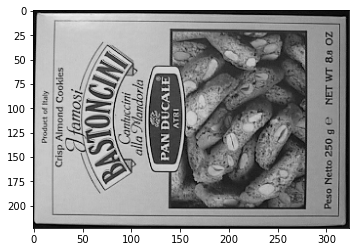

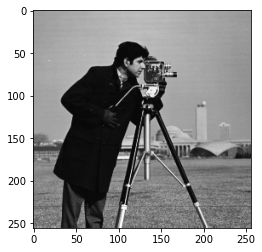

In [13]:
path_images = "./img/"
box = cv2.imread(path_images + "box.png", 0)
cameraman = cv2.imread(path_images + "cameraman.tif",0)
plt.imshow(box, "gray", vmin=0, vmax=255)
plt.figure()
plt.imshow(cameraman, "gray", vmin=0, vmax=255);

In [14]:
print("\n Image Box: \n")
kp_box = SIFT_Etapes_1_2_3(box, contrast_threshold=0.03)
print("\n Image Cameraman: \n")
kp_cameraman = SIFT_Etapes_1_2_3(cameraman, contrast_threshold=0.03)


 Image Box: 

--- ÉTAPE 1: DÉTECTION DES EXTREMA ---
[INFO] Taille de l'image chargée : (223, 324)
[INFO] Octaves DoG construites.
[INFO] Keypoints bruts détectés : 402

--- ÉTAPE 2: LOCALISATION PRÉCISE ---
[INFO] Keypoints conservés : 111

--- ÉTAPE 3: ASSIGNATION DES ORIENTATIONS ---
[INFO] Keypoints avec orientation avant déduplication : 173 points
[INFO] Keypoints avec orientation après déduplication : 173 points

 Image Cameraman: 

--- ÉTAPE 1: DÉTECTION DES EXTREMA ---
[INFO] Taille de l'image chargée : (256, 256)
[INFO] Octaves DoG construites.
[INFO] Keypoints bruts détectés : 257

--- ÉTAPE 2: LOCALISATION PRÉCISE ---
[INFO] Keypoints conservés : 84

--- ÉTAPE 3: ASSIGNATION DES ORIENTATIONS ---
[INFO] Keypoints avec orientation avant déduplication : 129 points
[INFO] Keypoints avec orientation après déduplication : 129 points


# Fonction affichage

In [15]:
def draw_keypoints_orientations_on_ax(ax, image, keypoints_with_orientation):
    """
    Visualise les keypoints et leurs orientations sur un subplot Matplotlib.
    
    Dessine les keypoints sous forme de points rouges et leurs orientations
    sous forme de flèches cyan.
    
    Args:
        ax (matplotlib.axes.Axes): Axe Matplotlib sur lequel dessiner.
        image (numpy.ndarray): Image de fond en niveaux de gris.
        keypoints_with_orientation (list): Liste de keypoints avec orientations.
    
    Returns:
        None: Modifie l'axe en place.
    """
    # Affichage de l'image de fond
    ax.imshow(image, cmap='gray')
    
    # Vérification si des keypoints existent
    if not keypoints_with_orientation:
        ax.set_title("Aucun keypoint trouvé")
        return

    # Extraction des coordonnées et propriétés
    X = [kp[2] for kp in keypoints_with_orientation]       # x_orig
    Y = [kp[3] for kp in keypoints_with_orientation]       # y_orig
    Sigmas = [kp[4] for kp in keypoints_with_orientation]  # effective_sigma
    Oris = [kp[5] for kp in keypoints_with_orientation]    # orientation_rad
    
    # Calcul des composantes des flèches d'orientation
    scale_factor = 3  # Facteur d'échelle pour la visualisation
    U = [scale_factor * s * np.cos(o) for s, o in zip(Sigmas, Oris)]  # Composante X
    V = [scale_factor * s * np.sin(o) for s, o in zip(Sigmas, Oris)]  # Composante Y

    # Affichage des keypoints
    ax.scatter(X, Y, c='red', label='Keypoints')
    
    # Affichage des orientations sous forme de flèches
    ax.quiver(X, Y, U, V, color='cyan', 
             scale=None, 
             scale_units='xy', 
             angles='xy',
             width=0.002,
             label='Orientations')
    
    # Configuration de l'axe
    ax.set_title(f"Keypoints SIFT ({len(keypoints_with_orientation)} points)")
    ax.legend()
    ax.set_xlabel("X Pixel")
    ax.set_ylabel("Y Pixel")
    ax.set_aspect('equal', adjustable='box')

#### SIFT d'OpenCV:

In [16]:
sift = cv2.SIFT_create(contrastThreshold=0.09)
#D'après la doc https://docs.opencv.org/4.x/d7/d60/classcv_1_1SIFT.html pour avoir le contrastTreshold du papier de
#Lowe (=0.03), il faut mettre contrastThreshold a 0.09.


img_box_opencv = cv2.imread(path_images + 'box.png')
gray= cv2.cvtColor(img_box_opencv,cv2.COLOR_BGR2GRAY)
kp_box_opencv = sift.detect(gray,None)
img_box_opencv=cv2.drawKeypoints(gray,kp_box_opencv,img_box_opencv)


img_cameraman_opencv = cv2.imread(path_images + 'cameraman.tif')
gray= cv2.cvtColor(img_cameraman_opencv,cv2.COLOR_BGR2GRAY)
kp_cameraman_opencv = sift.detect(gray,None)
img_cameraman_opencv=cv2.drawKeypoints(gray,kp_cameraman_opencv,img_cameraman_opencv)


# Comparaison des résultats:

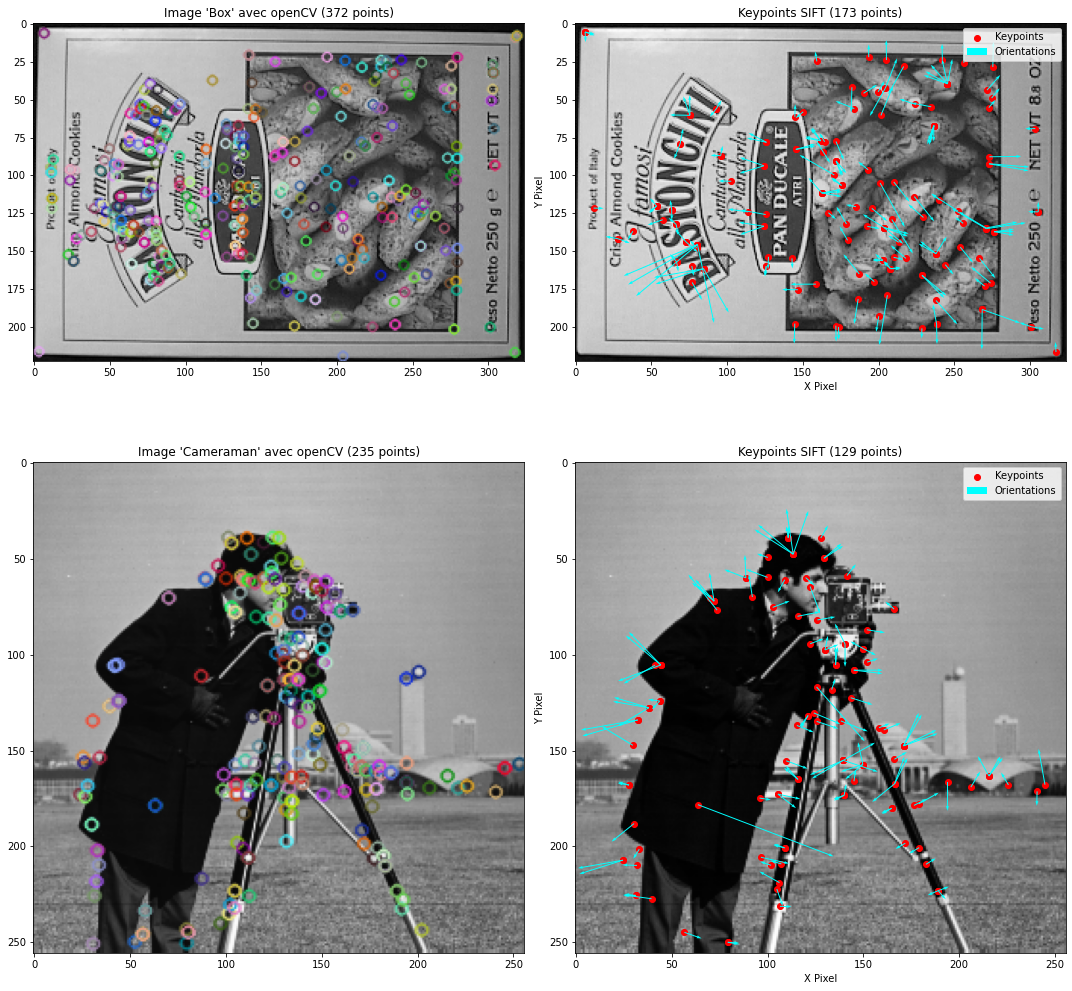

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))


axes[0, 0].imshow(img_box_opencv, cmap='gray')
axes[0, 0].set_title(f"Image 'Box' avec openCV ({len(kp_box_opencv)} points)")

draw_keypoints_orientations_on_ax(axes[0, 1], box, kp_box)

axes[1, 0].imshow(img_cameraman_opencv, cmap='gray')
axes[1, 0].set_title(f"Image 'Cameraman' avec openCV ({len(kp_cameraman_opencv)} points)")

draw_keypoints_orientations_on_ax(axes[1, 1], cameraman, kp_cameraman)

plt.tight_layout()
plt.show()